# Differentiable Optimization

An optimization problem can be a layer. For a quadratic objective

$$
\phi(z,x)=\frac12 z^\top A z-b_\theta(x)^\top z,
\qquad A=L L^\top+\lambda I,
$$

the stationarity condition is

$$
\nabla_z\phi(z,x)=Az-b_\theta(x)=0.
$$

The solution can be obtained directly by $Az=b_\theta(x)$, or by applying the
fixed-point map

$$
T(z)=z-\eta(Az-b_\theta(x)).
$$

<!-- silva-numbered-citations:start -->
**Numbered literature:** [8](https://jseluis.github.io/silva-networks/paper/references/#ref-8), [9](https://jseluis.github.io/silva-networks/paper/references/#ref-9), [40](https://jseluis.github.io/silva-networks/paper/references/#ref-40). Each number opens the complete citation and its primary external source.
<!-- silva-numbered-citations:end -->


In [1]:
from pathlib import Path
import importlib.util
import subprocess
import sys

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/jseluis/silva-networks.git"

def find_local_silva_root():
    candidates = [
        Path.cwd(),
        Path("/content/silva-networks"),
        Path("/content/drive/MyDrive/silva-networks"),
    ]
    root = Path.cwd()
    while root != root.parent:
        candidates.append(root)
        root = root.parent
    for candidate in candidates:
        if (candidate / "src" / "silva_networks").exists():
            return candidate
    return None

root = find_local_silva_root()
if root is not None:
    sys.path.insert(0, str(root / "src"))
elif IN_COLAB and importlib.util.find_spec("silva_networks") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", f"git+{REPO_URL}"])
    root = Path.cwd()
else:
    root = Path.cwd()

In [2]:
import math
import numpy as np
import torch
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})

from silva_networks import resolve_device, SolverConfig

torch.manual_seed(7)
np.random.seed(7)
device = resolve_device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

## Exact Solve and Fixed-Point Solve

The package layer exposes both the direct linear solve and the iterative
fixed-point version. This makes it easy to debug the optimization layer before
using it inside a larger model.

In [3]:
from silva_networks import silva_quadratic_optimization_layer

layer = silva_quadratic_optimization_layer(
    in_dim=3,
    state_dim=2,
    ridge=1.5,
    step_size=0.2,
    config=SolverConfig(max_iter=60, alpha=1.0, tol=1e-7),
    reengage=False,
).to(device)
x = torch.tensor([[1.0, -0.5, 0.25], [-0.2, 0.4, 0.7]], device=device)
iterative = layer(x)
exact = layer.exact_solution(x)
torch.max(torch.abs(iterative - exact)).detach().cpu()

tensor(4.4703e-08)

## Energy Decrease

The fixed-point map is gradient descent on $\phi$. The sequence below records
the objective value by hand, one update at a time.

In [4]:
z = torch.zeros_like(exact)
energies = []
for _ in range(25):
    energies.append(float(layer.energy(z, x).mean().detach().cpu()))
    z = layer.transition(z, x)
energies.append(float(layer.energy(z, x).mean().detach().cpu()))
energies[:3], energies[-1]

([0.0, -0.026493709534406662, -0.0331171378493309], -0.03532494604587555)

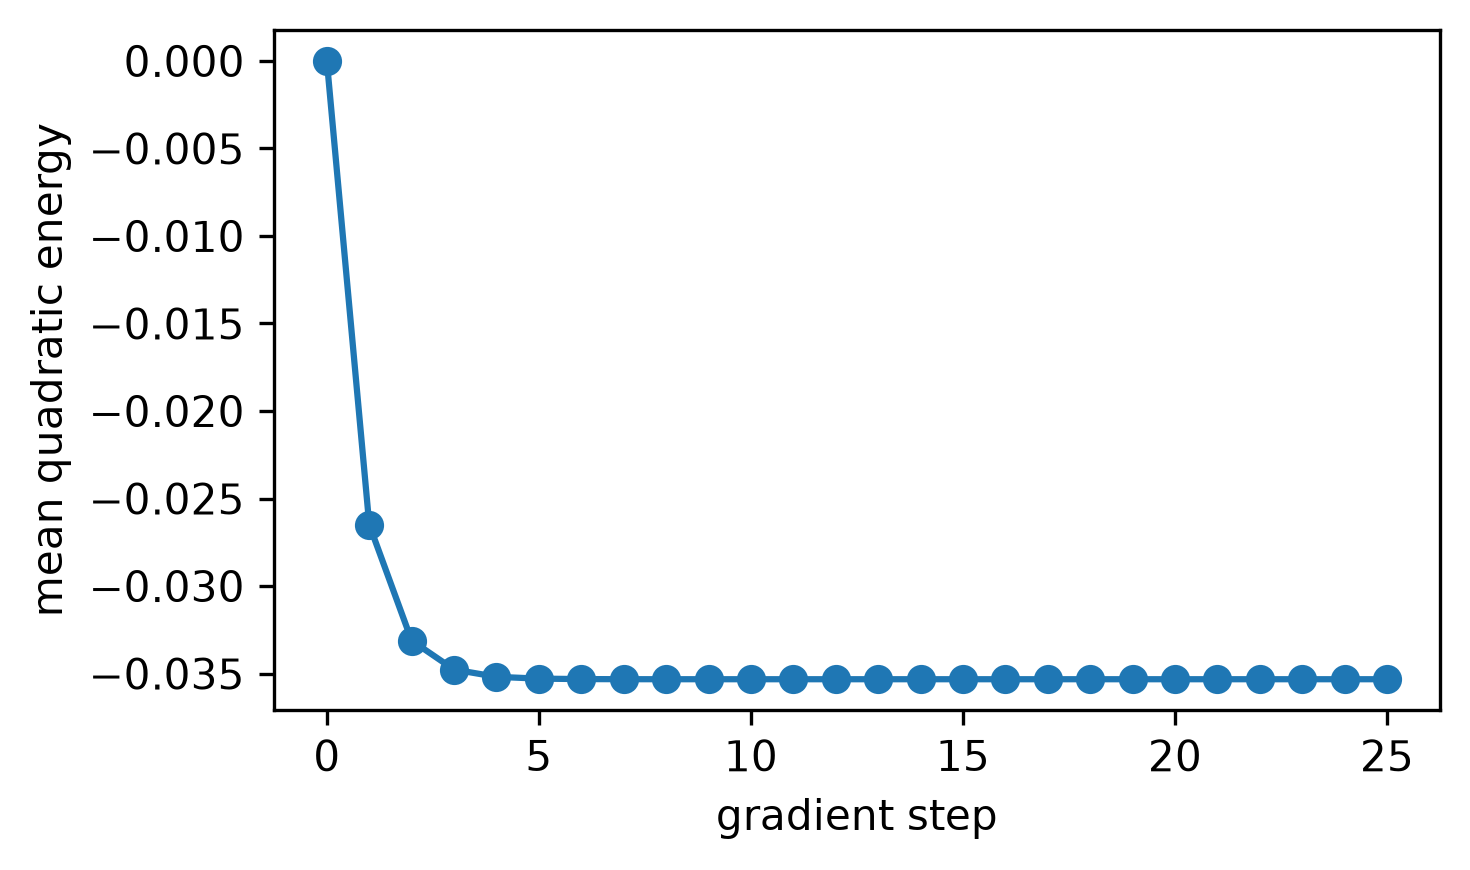

In [5]:
plt.figure(figsize=(5.0, 3.0))
plt.plot(energies, marker="o")
plt.xlabel("gradient step")
plt.ylabel("mean quadratic energy")
plt.tight_layout()

## Gradients Through the Layer

The objective parameters are PyTorch parameters. A downstream loss can update
the input-to-$b$ map and the positive-definite matrix factor.

In [6]:
target = torch.zeros_like(iterative)
optim = torch.optim.Adam(layer.parameters(), lr=0.01)
optim.zero_grad()
solution = layer(x)
loss = (solution - target).square().mean()
loss.backward()
optim.step()

float(loss.detach().cpu()), layer.b_proj.weight.grad is not None, layer.factor.grad is not None

(0.014129972085356712, True, True)

## Citation and Sources

If this package or notebook is used, cite the software repository:

```text
Dr. Jose Luis Silva. SILVA Networks. Version 1.1.0. MIT License.
https://github.com/jseluis/silva-networks
https://doi.org/10.5281/zenodo.21770098
```

When the work is connected to the SILVA methodology, cite the SILVA Networks
paper as well:

```text
Jose Luis Lima de Jesus Silva. SILVA Networks as Structured Implicit Layers and
Vector Attractors via Dynamic Interaction Fields. 2026. arXiv:2607.28989.
https://arxiv.org/abs/2607.28989
```

Background sources:

- Deep Implicit Layers tutorial: https://implicit-layers-tutorial.org/
- LocusLab DEQ repository: https://github.com/locuslab/deq
- Deep Equilibrium Models: https://arxiv.org/abs/1909.01377
- Multiscale Deep Equilibrium Models: https://arxiv.org/abs/2006.08656
- Stabilizing Equilibrium Models by Jacobian Regularization: https://arxiv.org/abs/2106.14342

The notebook is adapted to the `silva_networks` public API. It links to the
sources above and keep the examples package-native.

## From 05 Differentiable Optimization to a Custom SILVA Family

The construction in this notebook can be separated into the universal
conditioned-equilibrium contract

$$
z_0=I_\eta(x),\qquad
z^\star=T_\theta(z^\star,x),\qquad
\widehat y=Q_\psi(z^\star).
$$

For this topic:

| Part | Concrete interpretation |
| --- | --- |
| Equilibrium state | the primal variable and any dual or auxiliary state |
| Condition | objective coefficients and constraints |
| Repeated computation | a projected, proximal, or primal-dual update |
| Required invariants | feasibility, domain projection, state shape, and optimality conditions |
| Replaceable components | objective operator, projector/proximal map, transition, solver, and readout |

The initializer and source path are evaluated outside or alongside the root
solve. Only the state-preserving transition is repeated. Replacing an internal
architecture does not change this equation, provided the transition still maps
the same state space into itself.


In [7]:
import torch as silva_extension_torch
from torch import nn as silva_extension_nn

from silva_networks import (
    SILVAConditionedEquilibrium,
    SILVAZeroInitializer,
    SolverConfig,
    validate_silva_transition,
)


class NotebookExtensionTransition(silva_extension_nn.Module):
    def __init__(self, condition_dim=2, state_dim=3):
        super().__init__()
        self.source = silva_extension_nn.Linear(condition_dim, state_dim)
        self.state_field = silva_extension_nn.Sequential(
            silva_extension_nn.Linear(state_dim, 2 * state_dim),
            silva_extension_nn.Tanh(),
            silva_extension_nn.Linear(2 * state_dim, state_dim),
        )

    def forward(self, state, condition):
        return silva_extension_torch.tanh(
            self.source(condition) + 0.15 * self.state_field(state)
        )


silva_extension_torch.manual_seed(610)
notebook_condition = silva_extension_torch.linspace(-1.0, 1.0, 8).reshape(4, 2)
notebook_state0 = silva_extension_torch.zeros(4, 3)
notebook_transition = NotebookExtensionTransition()

notebook_report = validate_silva_transition(
    notebook_transition,
    notebook_state0,
    notebook_condition,
)
assert notebook_report.valid

with silva_extension_torch.no_grad():
    notebook_reference_step = silva_extension_torch.tanh(
        notebook_transition.source(notebook_condition)
        + 0.15 * notebook_transition.state_field(notebook_state0)
    )
silva_extension_torch.testing.assert_close(
    notebook_transition(notebook_state0, notebook_condition),
    notebook_reference_step,
)

notebook_custom_model = SILVAConditionedEquilibrium(
    notebook_transition,
    SILVAZeroInitializer(3),
    readout=silva_extension_nn.Linear(3, 1),
    config=SolverConfig(
        solver="picard",
        max_iter=40,
        tol=1e-7,
        backward_mode="implicit",
        backward_solver="gmres",
        anderson_batch_dims=1,
    ),
)
notebook_custom_result = notebook_custom_model(
    notebook_condition,
    return_result=True,
)
assert notebook_custom_result.output.shape == (4, 1)
assert notebook_custom_result.solver_result.residual < 1e-5

notebook_custom_result.output.square().mean().backward()
assert all(
    parameter.grad is not None and silva_extension_torch.isfinite(parameter.grad).all()
    for parameter in notebook_custom_model.parameters()
)
print("custom transition:", notebook_report)
print("equilibrium residual:", notebook_custom_result.solver_result.residual)


custom transition: SILVATransitionReport(state_shape=(4, 3), output_shape=(4, 3), preserves_shape=True, preserves_device=True, preserves_dtype=True, finite=True, differentiable=True, parameter_count=54)
equilibrium residual: 5.960464477539063e-08


## Numerical Equivalence, Compact Reproduction, and Scale

Before training, compare one packaged transition with an independently written
update:

$$
e_{\mathrm{step}}
=\frac{\|T_\theta(z,x)-T_{\mathrm{ref}}(z,x)\|_2}
{\|T_{\mathrm{ref}}(z,x)\|_2+\varepsilon}.
$$

After solving, report the fixed-point residual separately:

$$
e_{\mathrm{fp}}
=\frac{\|T_\theta(z^\star,x)-z^\star\|_2}
{\|z^\star\|_2+\varepsilon}.
$$

For this notebook, a compact reproduction must declare and assert
**objective gap, feasibility residual, KKT residual, and gradient error**. A full experiment must additionally record the
source dataset version and split, preprocessing, architecture widths, solver
and optimizer schedules, random seeds, baseline configuration, checkpoints,
and every deviation from the cited protocol.

The principal scaling axes are **variable count, constraint count, conditioning, and linear-solver budget**. Increase one axis at
a time, retain the compact deterministic case as a regression test, and record
task error, domain-specific residual, forward residual, backward linear
residual, memory use, and runtime independently.

### Extension Exercises

1. Replace one component from this notebook while preserving its state and
   domain invariants.
2. Write the replacement first as an independent reference function, then as
   a module, and assert one-step equivalence.
3. Compare two solver configurations on the identical trained transition.
4. Add a compact baseline and a predeclared metric threshold.
5. Create a full-scale configuration without weakening the compact tests.

The complete authoring protocol is documented in
[Extending SILVA](https://jseluis.github.io/silva-networks/learn/extending-silva/).


In [8]:
notebook_reproduction_record = {
    "notebook": '05_differentiable_optimization.ipynb',
    "state": 'the primal variable and any dual or auxiliary state',
    "condition": 'objective coefficients and constraints',
    "transition": 'a projected, proximal, or primal-dual update',
    "invariants": 'feasibility, domain projection, state shape, and optimality conditions',
    "compact_metric": 'objective gap, feasibility residual, KKT residual, and gradient error',
    "scale_axis": 'variable count, constraint count, conditioning, and linear-solver budget',
}
assert all(notebook_reproduction_record.values())
notebook_reproduction_record


{'notebook': '05_differentiable_optimization.ipynb',
 'state': 'the primal variable and any dual or auxiliary state',
 'condition': 'objective coefficients and constraints',
 'transition': 'a projected, proximal, or primal-dual update',
 'invariants': 'feasibility, domain projection, state shape, and optimality conditions',
 'compact_metric': 'objective gap, feasibility residual, KKT residual, and gradient error',
 'scale_axis': 'variable count, constraint count, conditioning, and linear-solver budget'}

## Where to Go Next

| Question | Page |
| --- | --- |
| Where is a constrained layer executed as a script? | [Constrained Optimization Example](https://jseluis.github.io/silva-networks/examples/constrained-optimization/) |
| Which optimization layers and constraints are public? | [Optimization API](https://jseluis.github.io/silva-networks/api/optimization/) |
| How do optimization layers fit the implicit viewpoint? | [Implicit Layers Bridge](https://jseluis.github.io/silva-networks/learn/implicit-bridge/) |
